<a href="https://colab.research.google.com/github/srijalgiri/Ai-ML_sem6/blob/main/2413995_Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - Worksheet 5
---

## Setup & Imports

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
from sklearn.metrics import classification_report

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## Configuration

In [3]:
# -------------------------------------------------------
# UPDATE THESE PATHS to point to your dataset folders
# Expected structure:
#   train/
#     pupunha/  guarana/  graviola/  tucuma/  acai/  cupuacu/
#   test/
#     pupunha/  guarana/  ...
# -------------------------------------------------------
TRAIN_DIR = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train'
TEST_DIR  = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/test'

IMG_HEIGHT    = 128
IMG_WIDTH     = 128
BATCH_SIZE    = 32
VAL_SPLIT     = 0.2
EPOCHS        = 250
TRAIN_BATCH   = 16   # batch size for training (Task 4)
SEED          = 123

---
## Task 1 – Data Understanding and Visualisation

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1a. Load and Visualise One Image per Class

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


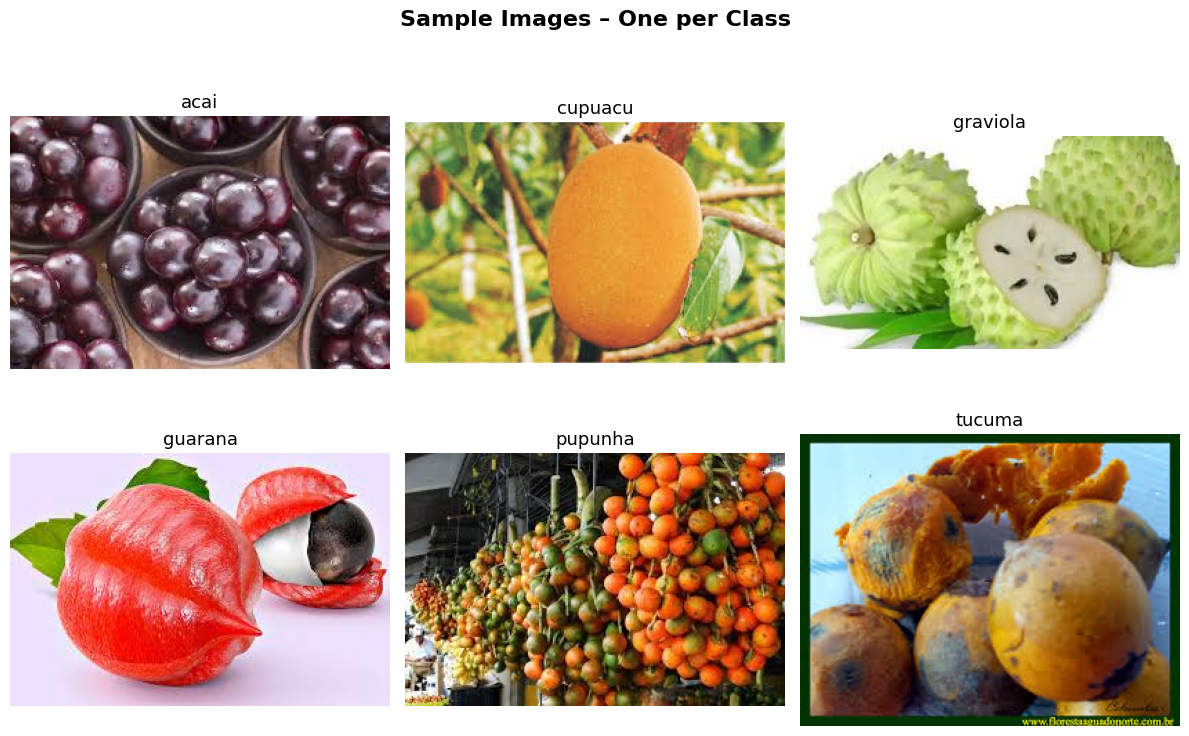


Observation: The dataset contains fruit images of varying sizes, backgrounds,
lighting conditions and orientations. Preprocessing (resize + normalise) is
therefore essential before training.


In [5]:
# Get all class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
num_classes = len(class_dirs)
print(f'Classes found ({num_classes}): {class_dirs}')

# Select one random image per class
sample_images = []
sample_labels = []
for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))]
    chosen = random.choice(images)
    sample_images.append(os.path.join(cls_path, chosen))
    sample_labels.append(cls)

# Display in a grid with 2 rows
cols = (num_classes + 1) // 2   # ceiling-divide for 2 rows
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=13)
    axes[i].axis('off')

# Hide any unused subplot slots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images – One per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObservation: The dataset contains fruit images of varying sizes, backgrounds,')
print('lighting conditions and orientations. Preprocessing (resize + normalise) is')
print('therefore essential before training.')

### 1b. Check for and Remove Corrupted Images

In [6]:
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        image_path = os.path.join(cls_path, fname)
        if not os.path.isfile(image_path):
            continue
        try:
            img = Image.open(image_path)
            img.verify()          # raises if file is corrupt
        except (IOError, SyntaxError):
            corrupted.append(image_path)
            os.remove(image_path)
            print(f'Removed corrupted image: {image_path}')

if not corrupted:
    print('No corrupted images found.')
else:
    print(f'\nTotal corrupted images removed: {len(corrupted)}')

No corrupted images found.


---
## Task 2 – Loading and Preprocessing Image Data

In [7]:
# Normalisation layer  (pixel values 0-255 → 0-1)
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ---------- Training dataset ----------
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=TRAIN_BATCH,
    shuffle=True,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED
)

# ⚠️ Save class_names BEFORE .map() — after map() the attribute is lost
class_names = train_ds_raw.class_names
num_classes  = len(class_names)
print('Class names :', class_names)
print('Num classes :', num_classes)

train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# ---------- Validation dataset ----------
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=TRAIN_BATCH,
    shuffle=False,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED
)
val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

# ---------- Test dataset ----------
test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=TRAIN_BATCH,
    shuffle=False,
    seed=SEED
)
test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))

# Performance optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


---
## Task 3 – Build the CNN Model

In [8]:
model = keras.Sequential([

    # ── Convolutional Block 1 ──────────────────────────────────
    layers.Conv2D(
        filters=32, kernel_size=(3, 3),
        padding='same', strides=1,
        activation='relu',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Convolutional Block 2 ──────────────────────────────────
    layers.Conv2D(
        filters=32, kernel_size=(3, 3),
        padding='same', strides=1,
        activation='relu'
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Fully Connected Network ────────────────────────────────
    layers.Flatten(),
    layers.Dense(64,  activation='relu'),   # Hidden Layer 1
    layers.Dense(128, activation='relu'),   # Hidden Layer 2
    layers.Dense(num_classes, activation='softmax')  # Output Layer
], name='CNN_Fruit_Classifier')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Fruit_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4 – Compile and Train the Model

In [9]:
# ── Compile ──────────────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ────────────────────────────────────────────────
checkpoint_cb = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=20,          # stop if val_loss doesn't improve for 20 epochs
    restore_best_weights=True,
    verbose=1
)

# ── Train ─────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.1931 - loss: 2.0227
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 343ms/step - accuracy: 0.1528 - loss: 2.1205 - val_accuracy: 0.0000e+00 - val_loss: 1.8975
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.2517 - loss: 1.7961
Epoch 2: val_accuracy improved from 0.00000 to 0.33333, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 0.3056 - loss: 1.7432 - val_accuracy: 0.3333 - val_loss: 1.6488
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.5028 - loss: 1.5357
Epoch 3: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step - accuracy: 0.4306 - loss: 1.5272 - val_accuracy: 0.1111 - val_loss: 1.7832
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.5892 - loss: 1.2176
Epoch 4: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.5972 - loss: 1.1905 - val_accuracy: 0.2222 - val_loss: 1.5418
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7115 - loss: 0.9115
Epoch 5: val_accuracy improved from 0.33333 to 0.83333, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - accuracy: 0.7083 - loss: 0.9313 - val_accuracy: 0.8333 - val_loss: 0.8892
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.8573 - loss: 0.7115
Epoch 6: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 0.8333 - loss: 0.6696 - val_accuracy: 0.7778 - val_loss: 0.8457
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9361 - loss: 0.3979
Epoch 7: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 0.9306 - loss: 0.3895 - val_accuracy: 0.6667 - val_loss: 0.7299
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9385 - loss: 0.2463
Epoch 8: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 305ms/step - accuracy: 0.9583 - loss: 0.2154 - val_accuracy: 0.8889 - val_loss: 0.3270
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9972 - loss: 0.1062
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.9861 - loss: 0.0980 - val_accuracy: 0.8333 - val_loss: 0.4895
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9972 - loss: 0.0658
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 504ms/step - accuracy: 0.9861 - loss: 0.0742 - val_accuracy: 0.8889 - val_loss: 0.2068
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 1.0000 - loss: 0.0263
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/step - accuracy: 1.0000 - loss: 0.0352 - val_accuracy: 0.8333 - val_loss: 0.7486
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 - loss: 

### Training & Validation Curves

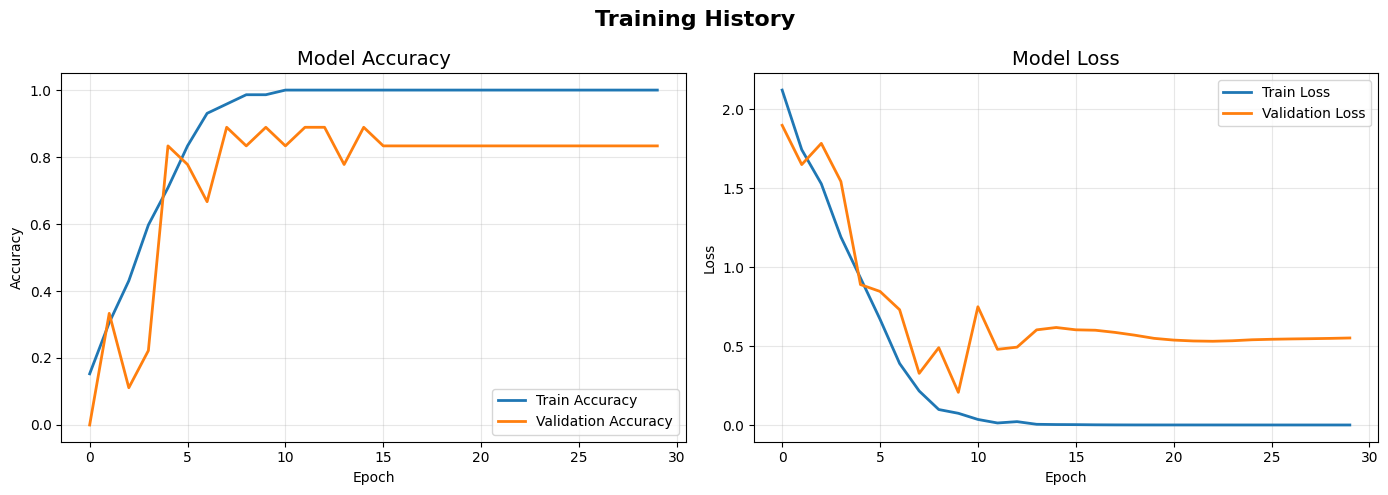

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss',      linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

---
## Task 5 – Evaluate the Model

In [11]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.7000 - loss: 0.6014

Test Loss     : 0.6014
Test Accuracy : 0.7000 (70.00%)


---
## Task 6 – Save and Reload the Model

In [12]:
# Save the final trained model
model.save('fruit_cnn_final.h5')
print('Model saved to fruit_cnn_final.h5')

# Reload and re-evaluate
loaded_model = keras.models.load_model('fruit_cnn_final.h5')
print('\nModel reloaded successfully.')

reloaded_loss, reloaded_acc = loaded_model.evaluate(test_ds)
print(f'Reloaded Model – Test Loss: {reloaded_loss:.4f} | Test Accuracy: {reloaded_acc:.4f}')

Model saved to fruit_cnn_final.h5

Model reloaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7000 - loss: 0.6014
Reloaded Model – Test Loss: 0.6014 | Test Accuracy: 0.7000


---
## Task 7 – Predictions and Classification Report

In [13]:
# Collect all true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true  = np.array(y_true)
y_pred  = np.argmax(np.array(y_pred_probs), axis=1)

print('Classification Report')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       1.00      0.60      0.75         5
    graviola       0.62      1.00      0.77         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.43      0.60      0.50         5

    accuracy                           0.70        30
   macro avg       0.77      0.70      0.69        30
weighted avg       0.77      0.70      0.69        30



### Visualise Predictions on Sample Test Images

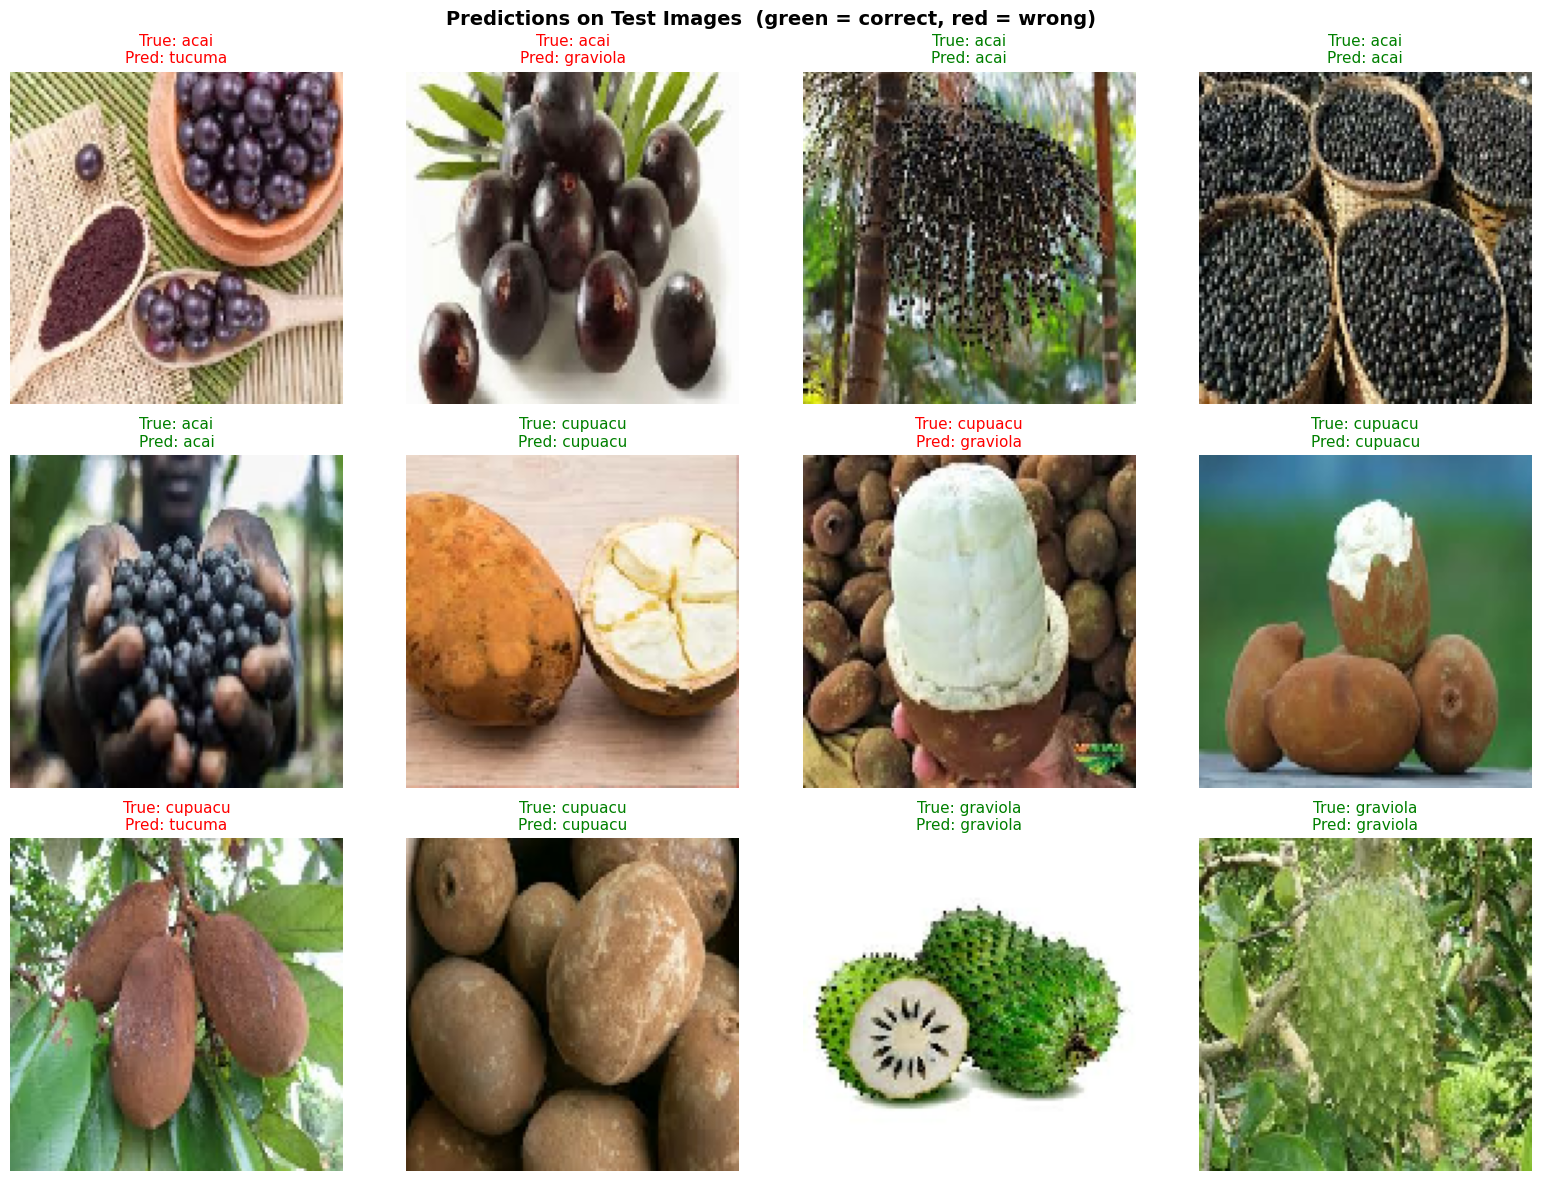

In [14]:
# Grab one batch of test images for visualisation
test_images_batch, test_labels_batch = next(iter(test_ds))
batch_preds = loaded_model.predict(test_images_batch, verbose=0)
batch_pred_labels = np.argmax(batch_preds, axis=1)

n_show = min(12, len(test_images_batch))
cols   = 4
rows   = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i in range(n_show):
    img   = test_images_batch[i].numpy()
    true  = class_names[test_labels_batch[i]]
    pred  = class_names[batch_pred_labels[i]]
    color = 'green' if true == pred else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f'True: {true}\nPred: {pred}', color=color, fontsize=11)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Predictions on Test Images  (green = correct, red = wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()